Bollywood EDA analysis

In [5]:
# importing the libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

!pip install gdown
import gdown

# Extract the file ID from the Google Drive link
file_id = '1dhg0foinB4iRrH13Rk64jpPwbpz7gwzn'

# Download to a temporary file
output = 'bollywood.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output, quiet=False)
# reading the dataset
df = pd.read_csv(output)

# viewing the first few rows of the dataset
# the head() function displays the first 5 rows of the dataframe
df.head(150)

Downloading...
From: https://drive.google.com/uc?id=1dhg0foinB4iRrH13Rk64jpPwbpz7gwzn
To: C:\Users\ASUS\bollywood.csv
100%|██████████| 9.02k/9.02k [00:00<00:00, 4.51MB/s]


,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527.0
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137.0
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54.0
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19.0
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224.0
...,...,...,...,...,...,...,...,...,...,...
144,145,27-Feb-15,Dum Laga Ke Haisha,N,Comedy,15,30.00,3250917,8185,615.0
145,146,13-Mar-15,NH10,N,Thriller,13,32.10,5592977,15464,1513.0
146,147,20-Mar-15,Dilliwali Zaalim Girlfriend,N,Comedy,32,12.00,2316047,4289,807.0
147,148,20-Mar-15,Hunterrr,N,Comedy,5,11.89,4674795,3706,762.0


Data Overview and Cleaning

Insight #1:
The dataset contains 149 records of movies released between 2013 and 2015. A quick data check reveals that the date column needed conversion and that the numerical fields (Budget, BoxOfficeCollection, and YouTube metrics) are right-skewed with some extreme values.

In [7]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
df.info()

# Check for missing values in each column
print("\nMissing Values:\n", df.isnull().sum())

# Convert 'Release Date' to datetime. The dates are in the format '18-Apr-14'
df['Release Date'] = pd.to_datetime(df['Release Date'], format='%d-%b-%y', errors='coerce')

# Show summary statistics for numerical columns
df[['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']].describe()


Dataset Shape: (149, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 149 non-null    int64  
 1   Release Date         149 non-null    object 
 2   MovieName            149 non-null    object 
 3   ReleaseTime          149 non-null    object 
 4   Genre                149 non-null    object 
 5   Budget               149 non-null    int64  
 6   BoxOfficeCollection  149 non-null    float64
 7   YoutubeViews         149 non-null    int64  
 8   YoutubeLikes         149 non-null    int64  
 9   YoutubeDislikes      146 non-null    float64
dtypes: float64(2), int64(4), object(4)
memory usage: 11.8+ KB

Missing Values:
 SlNo                   0
Release Date           0
MovieName              0
ReleaseTime            0
Genre                  0
Budget                 0
BoxOfficeCollection    0
YoutubeViews  

,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
count,149.000000,149.000000,1.490000e+02,149.000000,146.000000
mean,29.442953,55.667248,3.337920e+06,7877.536913,1198.000000
std,28.237981,94.494531,3.504407e+06,12748.047191,1863.792134
min,2.000000,0.010000,4.354000e+03,1.000000,1.000000
25%,11.000000,8.780000,1.076591e+06,1377.000000,194.750000
50%,21.000000,28.000000,2.375050e+06,4111.000000,613.500000
75%,35.000000,57.450000,4.550051e+06,9100.000000,1387.250000
max,150.000000,735.000000,2.317107e+07,101275.000000,11888.000000


Distribution of Budgets and Box Office Collections

Insight #2:
Both the Budget and Box Office Collection distributions are heavily right-skewed. This suggests that while most films have moderate budgets and returns, a few films are outliers with exceptionally high values.

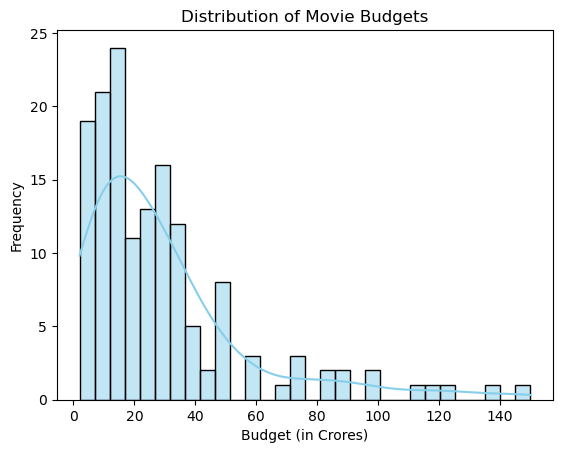

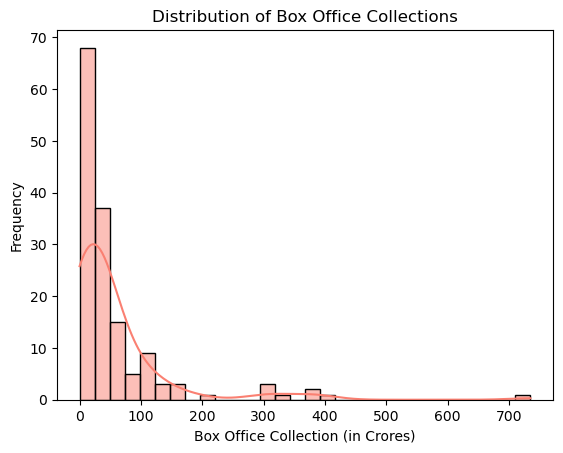

In [9]:
# Plot the distribution of movie budgets
sns.histplot(df['Budget'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Movie Budgets')
plt.xlabel('Budget (in Crores)')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of box office collections
sns.histplot(df['BoxOfficeCollection'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Box Office Collections')
plt.xlabel('Box Office Collection (in Crores)')
plt.ylabel('Frequency')
plt.show()


Relationship Between Budget and Box Office Collection

Insight #3:
There is a positive trend between a film’s budget and its box office collection. Higher-budget films tend to generate higher returns, although the presence of outliers indicates that other factors also contribute to box office success.

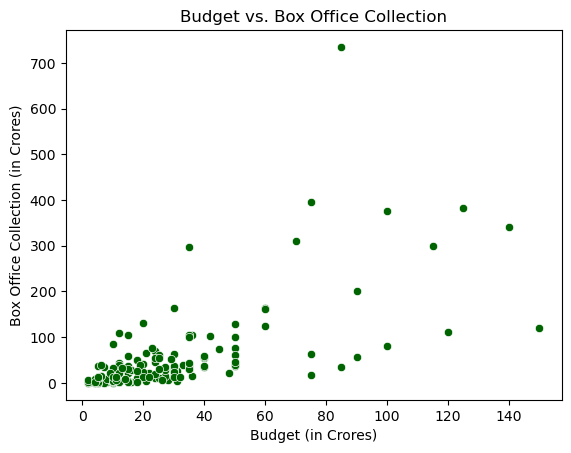

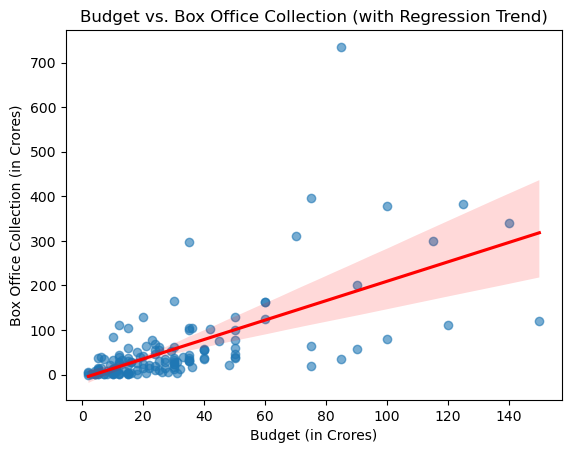

In [11]:
# Scatter plot to examine the relationship between Budget and Box Office Collection
sns.scatterplot(x='Budget', y='BoxOfficeCollection', data=df, color='darkgreen')
plt.title('Budget vs. Box Office Collection')
plt.xlabel('Budget (in Crores)')
plt.ylabel('Box Office Collection (in Crores)')
plt.show()

# Regression plot to better visualize the trend
sns.regplot(x='Budget', y='BoxOfficeCollection', data=df, 
            scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
plt.title('Budget vs. Box Office Collection (with Regression Trend)')
plt.xlabel('Budget (in Crores)')
plt.ylabel('Box Office Collection (in Crores)')
plt.show()


Analysis Based on Release Time

Insight #4:
Movies released during special time periods—such as Long Weekends (LW), Festive Seasons (FS), or Holiday Seasons (HS)—often have different box office performance compared to those released on normal days (N). This suggests that the timing of a release can significantly affect a film's earnings.

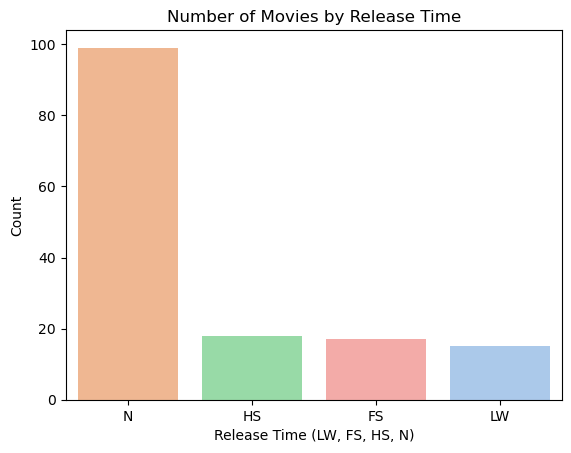

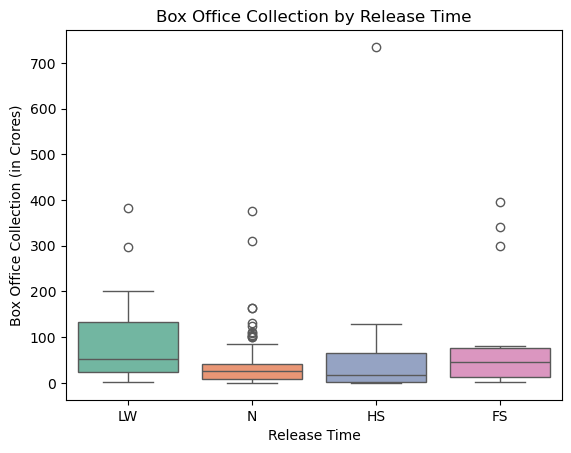

In [17]:
# Count of movies by ReleaseTime category (LW, FS, HS, N)
sns.countplot(x='ReleaseTime', hue='ReleaseTime', data=df, legend=False, 
              order=df['ReleaseTime'].value_counts().index, palette='pastel')
plt.title('Number of Movies by Release Time')
plt.xlabel('Release Time (LW, FS, HS, N)')
plt.ylabel('Count')
plt.show()

# Box plot showing distribution of Box Office Collection by ReleaseTime
sns.boxplot(x='ReleaseTime', y='BoxOfficeCollection', hue='ReleaseTime', data=df, legend=False, palette='Set2')
plt.title('Box Office Collection by Release Time')
plt.xlabel('Release Time')
plt.ylabel('Box Office Collection (in Crores)')
plt.show()


Genre-Wise Analysis

Insight #5:
Certain genres (such as Action or Thriller) tend to have higher average box office collections. This likely reflects differences in production scales, marketing strategies, and audience preferences across genres.

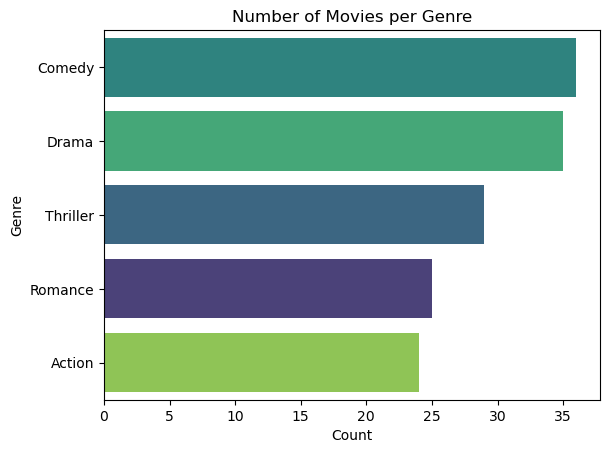

Average Box Office Collection by Genre:
 Genre
Action      91.680833
Drama       65.793143
Romance     52.841200
Comedy      46.115000
Thriller    27.936207
Name: BoxOfficeCollection, dtype: float64


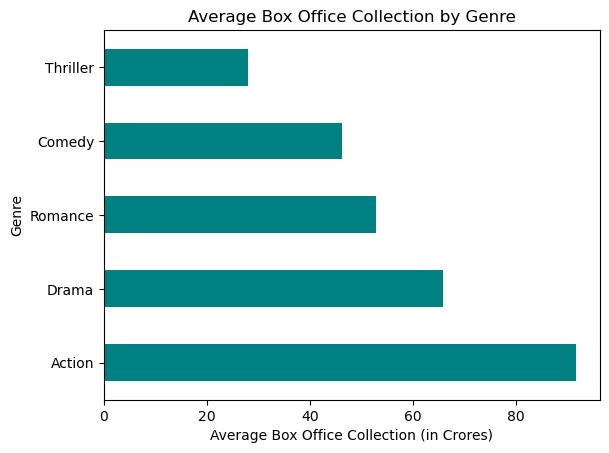

In [21]:
# Count plot of movies by Genre
sns.countplot(y='Genre', hue='Genre', data=df, legend=False, order=df['Genre'].value_counts().index, palette='viridis')
plt.title('Number of Movies per Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# Calculate the average Box Office Collection for each Genre
genre_avg = df.groupby('Genre')['BoxOfficeCollection'].mean().sort_values(ascending=False)
print("Average Box Office Collection by Genre:\n", genre_avg)

# Bar plot for average Box Office Collection by Genre
genre_avg.plot(kind='barh', color='teal')
plt.title('Average Box Office Collection by Genre')
plt.xlabel('Average Box Office Collection (in Crores)')
plt.ylabel('Genre')
plt.show()


Social Media Metrics Versus Box Office Performance

Insight #6:
A positive association is observed between social media engagement (YouTube views and likes) and box office collections. This implies that higher pre-release online buzz might be linked to better theatrical performance.

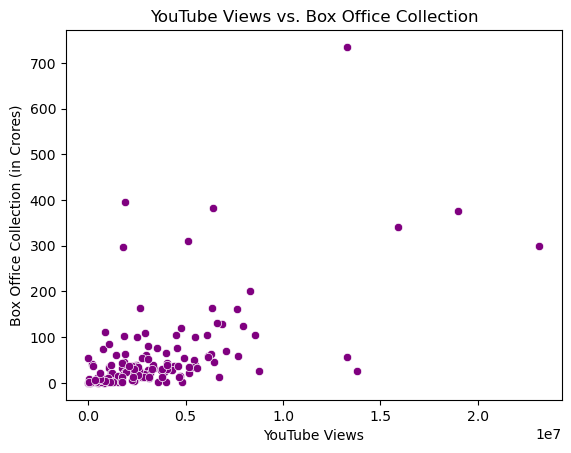

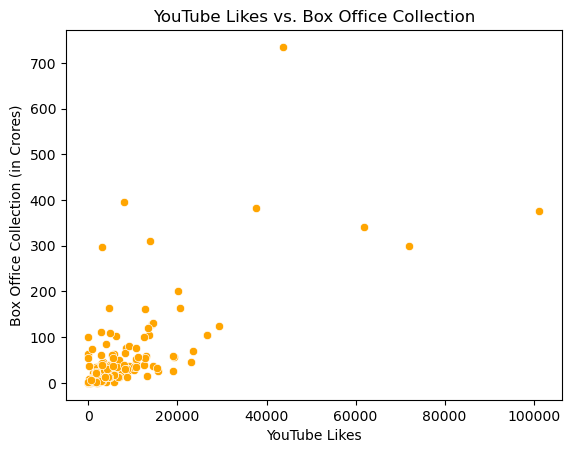

In [23]:
# Scatter plot: YouTube Views vs. Box Office Collection
sns.scatterplot(x='YoutubeViews', y='BoxOfficeCollection', data=df, color='purple')
plt.title('YouTube Views vs. Box Office Collection')
plt.xlabel('YouTube Views')
plt.ylabel('Box Office Collection (in Crores)')
plt.show()

# Scatter plot: YouTube Likes vs. Box Office Collection
sns.scatterplot(x='YoutubeLikes', y='BoxOfficeCollection', data=df, color='orange')
plt.title('YouTube Likes vs. Box Office Collection')
plt.xlabel('YouTube Likes')
plt.ylabel('Box Office Collection (in Crores)')
plt.show()


Time Series Analysis: Yearly Trends

Insight #7:
The analysis shows varying average box office collections across the years 2013 to 2015. Such trends could be indicative of changes in market dynamics, production quality, or promotional strategies over time.

Yearly Average Box Office Collection:
 Year
2013    51.763433
2014    61.671571
2015    42.438333
Name: BoxOfficeCollection, dtype: float64


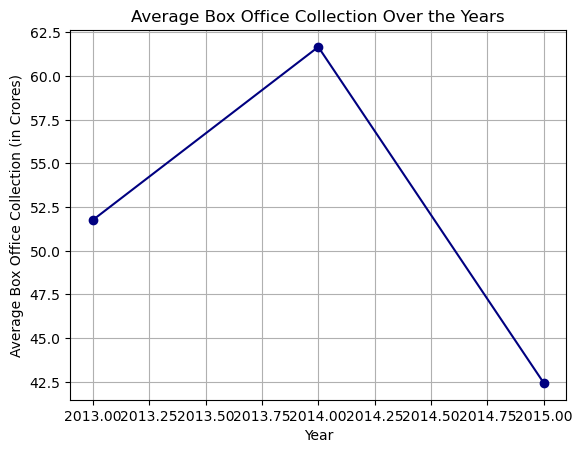

In [25]:
# Extract year from the 'Release Date'
df['Year'] = df['Release Date'].dt.year

# Calculate the average Box Office Collection per year
yearly_avg = df.groupby('Year')['BoxOfficeCollection'].mean()
print("Yearly Average Box Office Collection:\n", yearly_avg)

# Line plot to visualize the trend over years
yearly_avg.plot(kind='line', marker='o', color='navy')
plt.title('Average Box Office Collection Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Box Office Collection (in Crores)')
plt.grid(True)
plt.show()
